# Practical 5:   Phase-field method: basics and application in materials science

**Course:** Materials Simulation Practical  
**Supervisor:** Frank Wendler  
**Chair:** Chair of Materials Simulation (WW8)  
**Student:** Huseyn Shahhuseynov

<br><br>



## Task 1.

<br><br>

The objective of the task is simulate the solidification process using a one-dimensional phase-field model, where the order parameter $\phi(x,t)$ distinguishes between two coexisting phases, namely liquid ($\phi = 0$) and solid ($\phi = 1$). The system’s behavior is governed by a free-energy functional that depends on both the local value of $\phi$ and its spatial gradients. This functional is written as:

<br><br>

$$
F = \int { \underbrace{\left( f_{0} \phi^2 ( 1 - \phi )^2 + \frac{K_{\phi}} {2} \left|\nabla \phi \right|^2 \right)}_{f (\phi, \nabla \phi)} \, d \vec {r} } 
$$

<br><br>

The first term, $f \phi^2 (1 - \phi)^2$, represents the bulk free energy density, which has two minima at $\phi = 0$ and $\phi = 1$, corresponding to two stable phases, the thermodynamically stable liquid and solid phases. The second term, $\frac {K_{\phi}} {2} |\nabla \phi|^2$, represents the gradient-energy penalty, which accounts for the energetic cost of having a spatial variation in $\phi$. This term ensures that the solid–liquid interface acquires a finite thickness rather than being a sharp discontinuity.

The temporal evolution of the order parameter follows a relaxation dynamics that reduces the total free energy, given by the Allen–Cahn-type equation:

<br><br>

$$
\frac { \partial \phi } { \partial t } = - L \frac { \delta F } { \delta \phi }
$$

<br><br>

Here $L$ is a kinetic coefficient determining how quickly $\phi$ evolves, and $\frac { \delta F } { \delta \phi }$ is the variational derivative of the free energy functional, defined as:

<br><br>

$$
\frac { \delta F } { \delta \phi } = \frac { \partial f } { \partial \phi } - \nabla \cdot \frac { \partial f } { \partial ( \nabla \phi ) }
$$

<br><br>

Substituting the specific form of $f(\phi, \nabla \phi)$) gives the following terms.
The first contribution, from the bulk free energy, is:
<br><br>

$$
\frac { \partial f } { \partial \phi } = \frac { \partial } { \partial \phi } \left(f_{0} \phi^2 ( 1 - \phi )^2 \right) = 2 f_{0} \space \phi \space ( 1 - \phi ) ( 1 - 2\phi )
$$

<br><br>

The second contribution, from the gradient term, is:

<br><br>

$$
\nabla \cdot \frac { \partial f } { \partial ( \nabla \phi ) } = \nabla \cdot \frac { \partial } { \partial ( \nabla \phi ) } \left( \frac{K_{\phi}} {2} \left|\nabla \phi \right|^2 \right) =  \nabla \cdot \frac { \partial } { \partial ( \nabla \phi ) } \left( \frac{K_{\phi}} {2} \space \nabla \phi \cdot \nabla \phi \right) = K_{\phi} \space \nabla^2 \phi
$$

<br><br>

By combining the results, the analytical expression of the variational derivative $\frac { \delta F } { \delta \phi }$ is obtained:

<br><br>

$$
\frac { \delta F } { \delta \phi } = 2 f_{0} \space \phi \space ( 1 - \phi ) ( 1 - 2\phi ) - K_{\phi} \space \nabla^2 \phi
$$

<br><br>

Inserting this result into the governing equation yields:

<br><br>

$$
\frac { \partial \phi } { \partial t } = - L \left[ 2 f_{0} \space \phi \space ( 1 - \phi ) ( 1 - 2\phi ) - K_{\phi} \space \nabla^2 \phi \right]
$$

<br><br>

or equivalently,

<br><br>

$$
\frac { \partial \phi } { \partial t } = - L \left[ 2 f_{0} (\phi - 3 \phi^2 - 2 \phi^3) - K_{\phi} \space \nabla^2 \phi \right]
$$

<br><br>

This equation governs the evolution of the solid–liquid interface during solidification.
The first term in brackets drives the system toward the stable bulk phases, while the second term acts to smooth the interface. Over time, these competing effects lead to the formation of a stable diffuse interface between the solid and liquid regions, minimizing the total free energy of the system.

<br><br>

The above equation will be solved numerically using the FiPy finite-volume method in one spatial dimension. The computational domain had a length of $L_x=200$ with a grid spacing of 
$\delta x=0.1$, and the simulation was run for 100 time steps with a time increment of $\delta t=0.1$. Model parameters were set as $𝑓_0 = 1$, $K_{\phi}=1$, and $L=1$. The initial condition was a step function representing a solid–liquid interface, where the left half of the domain ($x<100$) corresponded to the solid phase ($\phi=1$) and the right half to the ($\phi=0$). No noise was added. Dirichlet and Neumann boundary conditions were applied at the left ($\phi=1$) and right ($\partial_{x} \phi=1$) boundaries, respectively, allowing the interface to relax toward equilibrium.

<br>

| 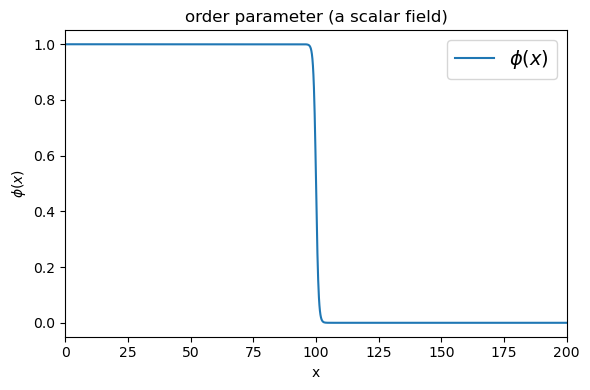 | 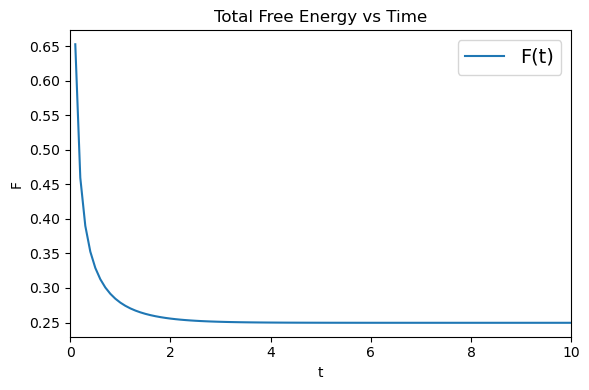 | 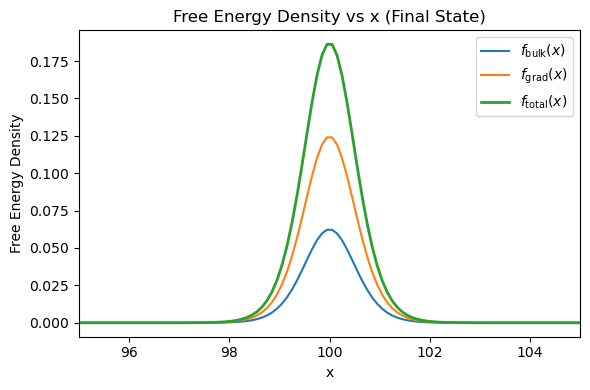 |
|:------------------------------------:|:------------------------------------------:|:------------------------------------------:|
| **Figure 1.** φ(x) | **Figure 2.** F(t) | **Figure 3.** Free-energy density components |

<br>

The simulation shows isothermal relaxation of a pre-existing sharp solid–liquid interface into a diffuse equilibrium profile. As seen in Figure 1, the order parameter $\phi(x)$ smoothly transitions from 1 (solid) to 0 (liquid) around $x\approx100$, forming a steady interface with a finite thickness.
The total free energy $F(t)$ in Figure 2 decreases rapidly at early times and gradually approaches a constant value, indicating that the system evolves toward a stable minimum of the free-energy functional.
In the final free-energy density distribution shown in Figure 3, both the bulk and gradient contributions peak at the interface, while they vanish in the uniform solid and liquid regions, which verifies that the energetic cost is localized at the interfacial region, and the final steady state corresponds to the minimum total free energy of the system.

<br><br>

**Parametric Study: Influence of Model Coefficients on the Phase-Field Evolution and Energy Landscape**

<br>

In this part of  the task, a parametric study was carried out to examine how variations in the model parameters affect the phase-field evolution and the corresponding energy landscape. The influence of the bulk free-energy coefficient $f_0$, the gradient energy coefficient $K_{\phi}$, and the mobility parameter $L$ was investigated with respect to the order parameter profile, total free energy, and local energy density distributions.

<br>

1. Influence of $f_0$ on the Phase-Field Evolution and Energy Landscape.

The parameter $f_0$ defines the depth of the double-well potential in the bulk free-energy density $f_{bulk} = f_0 \phi^2 (1-\phi)^2$. By increasing $f_0$, the energetic penalty for intermediate values of $\phi$ is raised, resulting in a sharper and narrower solid–liquid interface and an increase in total interfacial energy. When $f_0$ is reduced, the potential wells become shallower, and the interface becomes more diffuse with lower energy. The order parameter profiles, total free energy $F(t)$, and spatial distributions of $f_{bulk}(x)$, $f_{grad}(x)$, and $f_{total}(x)$ were obtained for $f_0 = 0.1, 0.5, 1.0 \text{, and } 2.0$ to illustrate these effects.

<br>

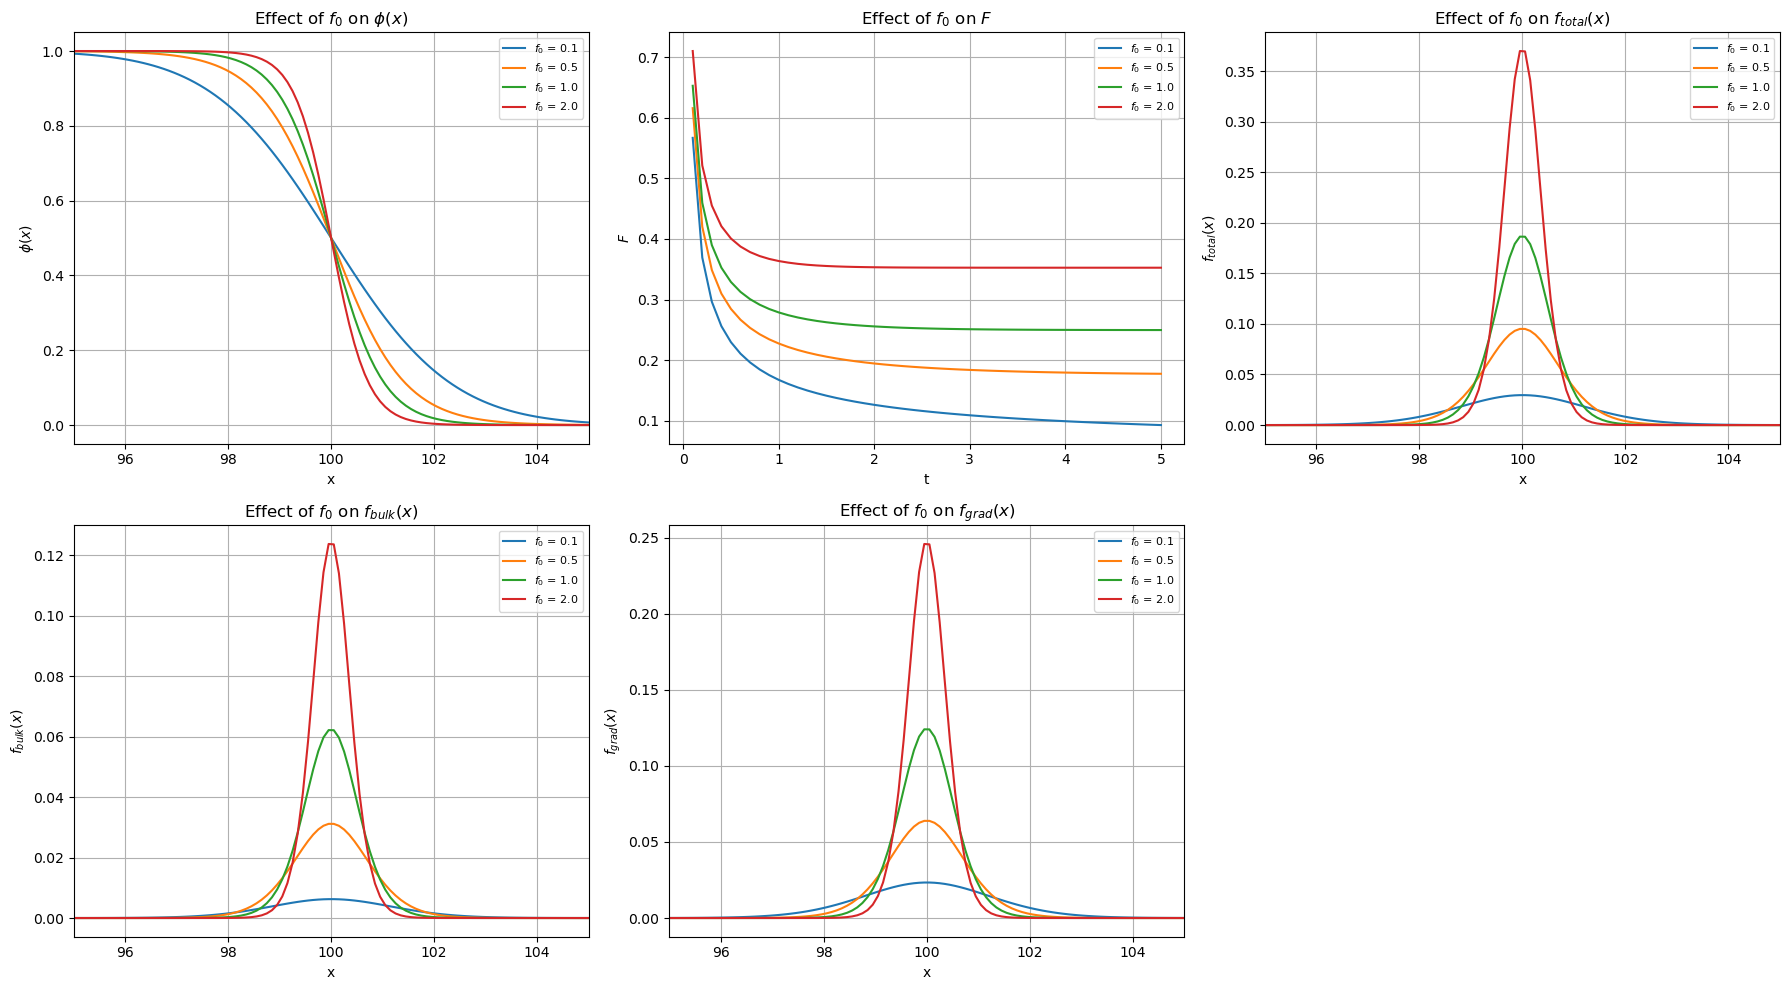

<br>

Note: Although $f_0$ and $K_{phi}$ appear as independent coefficients in the free-energy functional where they scale the bulk and gradient contributions, respectively, their effects are coupled through the equilibrium condition obtained from energy minimization. Changes in either parameter modify the balance between the bulk driving force and interfacial stiffness, thereby altering the equilibrium profile $\phi(x)$ and consequently affecting both $f_{bulk}$ and $f_{grad}$.

<br>


2. Influence of $K_{\phi}$ on the Phase-Field Evolution and Energy Landscape.

The coefficient $K_{\phi}$ governs the penalty associated with spatial gradients of the order parameter. An increase in $K_{\phi}$ leads to a broader and smoother interface, as stronger gradient energy suppresses steep variations of $\phi(x)$. Consequently, the local free-energy densities decrease in magnitude, and the interface becomes more extended. In contrast, lower values of $K_{\phi}$ produce a steeper and thinner interface with higher localized energy density. The order parameter profiles, total free energy $F(t)$, and spatial distributions of $f_{bulk}(x)$, $f_{grad}(x)$, and $f_{total}(x)$ were obtained for $K_{\phi} = 0.5, 1.0, 2.0 \text{, and } 4.0$ to illustrate these effects.

<br>

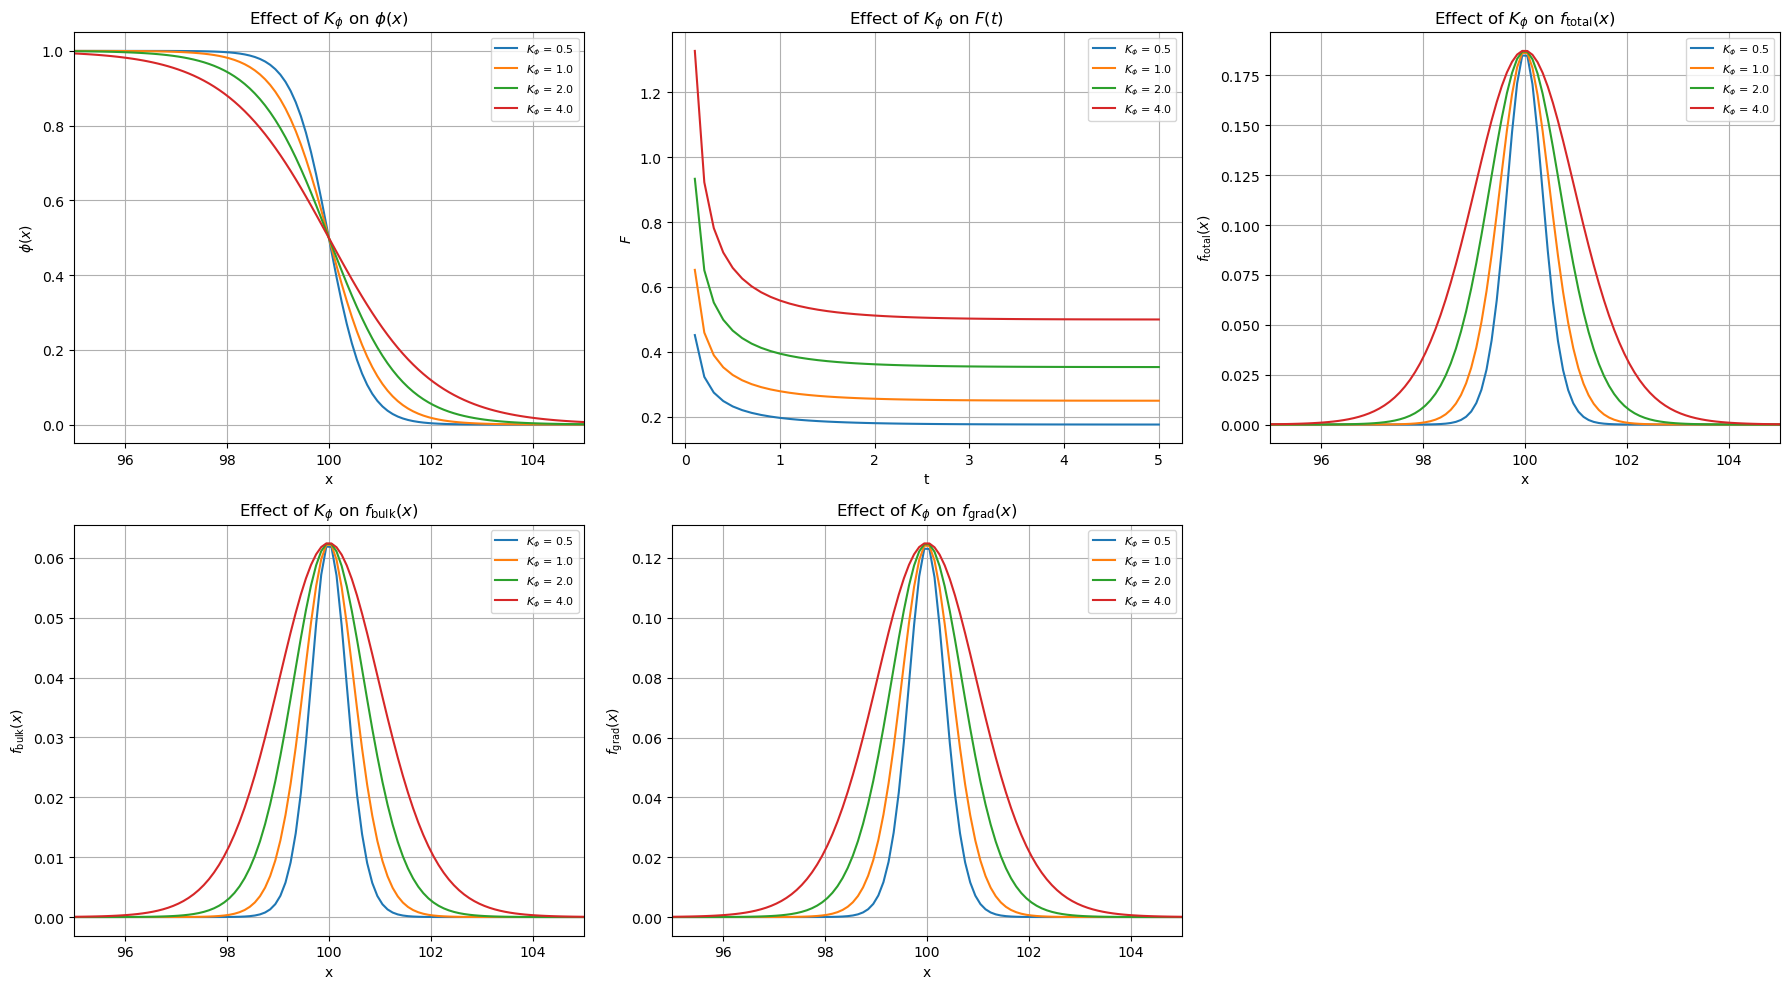

<br>

3. Influence of $L$ on the Phase-Field Evolution and Energy Landscape.

The kinetic coefficient $L$ determines the rate at which the system relaxes toward equilibrium. Variations in $L$ modify only the temporal evolution of the order parameter and total free energy but have no influence on the equilibrium state. Higher values of $L$ result in a faster approach to equilibrium, whereas lower values slow down the relaxation process. The final interface shape and total free energy remain identical for all values of $L$, confirming that $L$ affects kinetics but not thermodynamic equilibrium. The order parameter profiles, total free energy $F(t)$, and spatial distributions of $f_{bulk}(x)$, $f_{grad}(x)$, and $f_{total}(x)$ were obtained for $L = 0.5, 1.0, 2.0 \text{, and } 4.0$ to illustrate these effects.

<br>

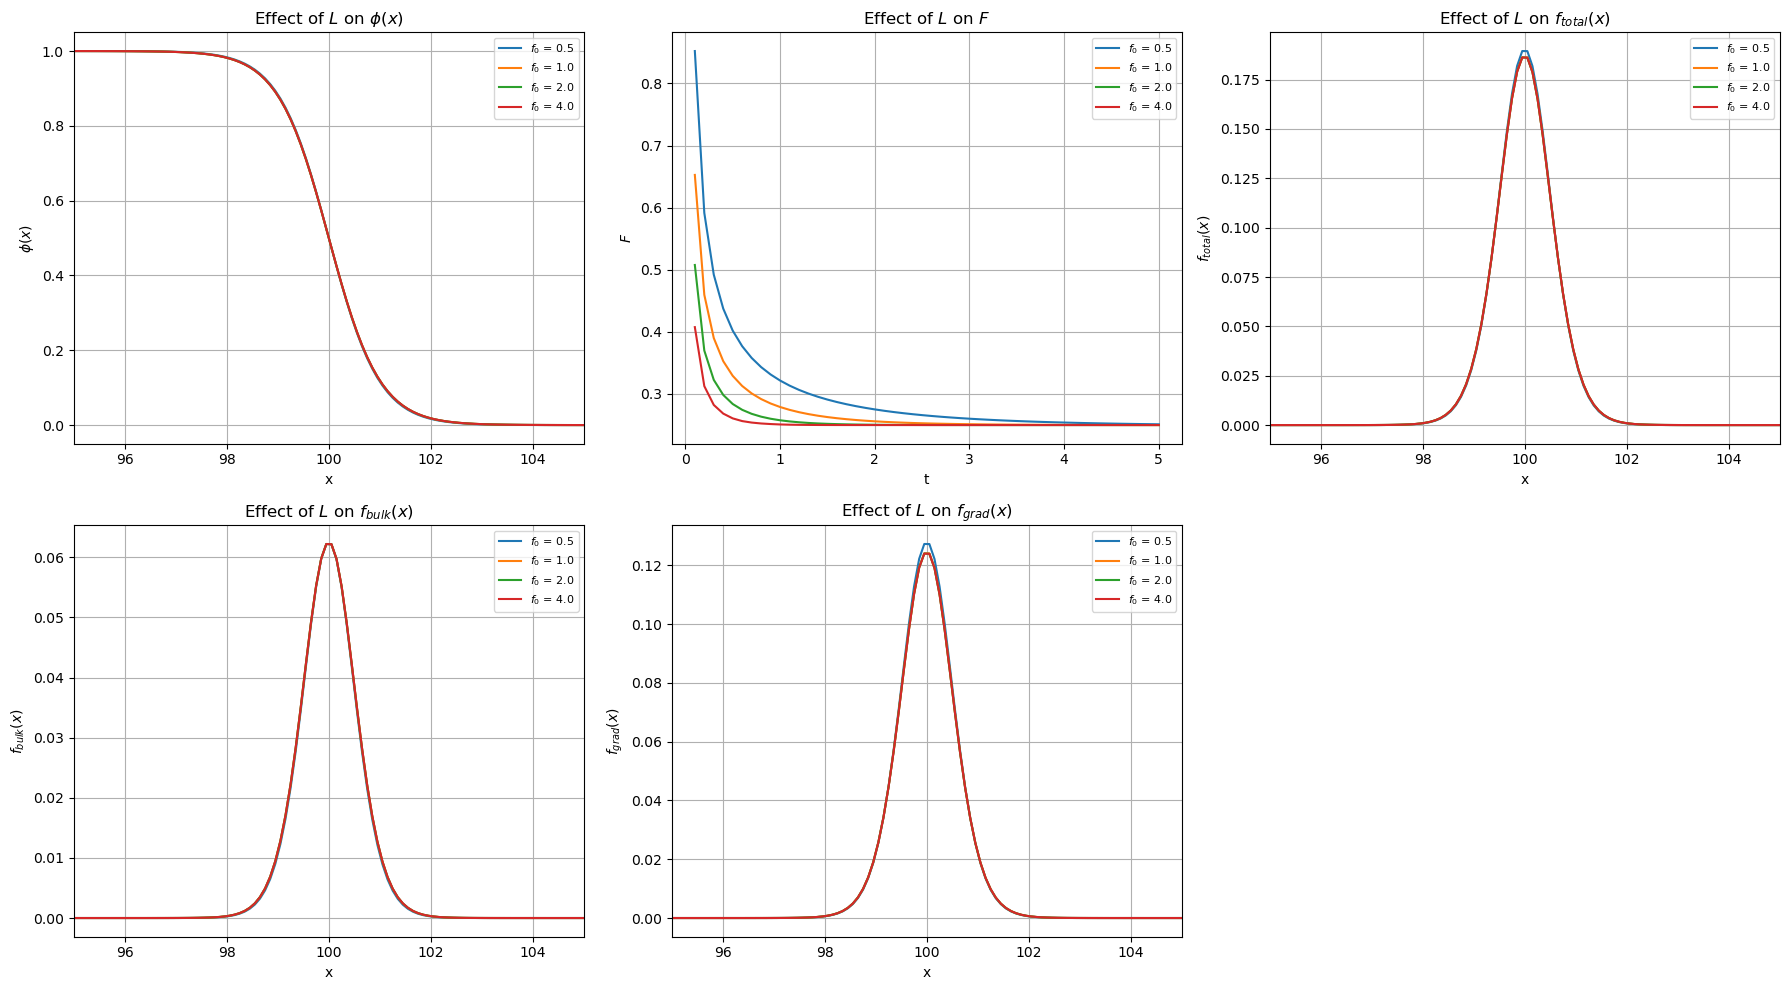

<br><br>

## Task 2

<br><br>

As it is given in the task, the bulk energy density is constructed as:

<br>

$$
f_{bulk} = f_{0} (c_{\gamma'}^e - c)^2 (c - c_{\gamma}^e)^2
$$

<br>

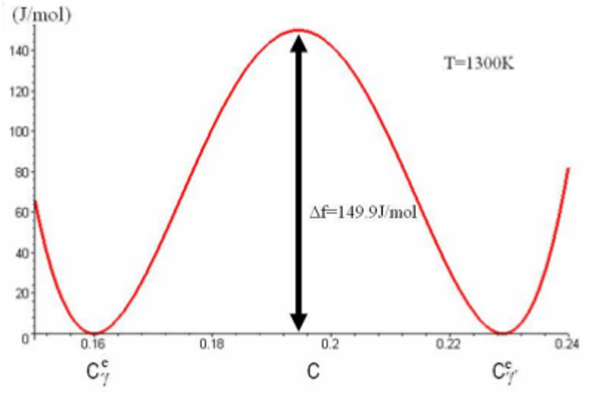

<br>

From the plot, the following values can be deducted:

<br>

$$
c_{\gamma'}^e = 0.23 \quad c_{\gamma}^e = 0.16 \quad c_{mid} = 0.195 \quad \text{ Symmetric double-well potential: $ c_{mid} = \frac {c_{\gamma'}^e +c_{\gamma}^e} {2}$ } \quad f_{bulk} (c_{mid} = 0.195) = \Delta f = 149.9 \frac {J}{mol}
$$

<br>

By inserting these values, the coefficient $f_{0}$ is determined from

<br>

$$
149.9 \frac {J}{mol} = f_{0} (0.23 - 0.195)^2 (0.195 - 0.16)^2
$$

$$
f_{0} = 9.989 \cdot 10^7 \frac {J}{mol} = 99.89 \frac {MJ}{mol}
$$

<br><br>

## Task 3

<br>

In this task, the evolution of a conserved order parameter, namely the concentration field $c(x,t)$, was modeled to describe diffusion-controlled phase separation. Because the total concentration must remain conserved during the process, the governing dynamics are described by the Cahn–Hilliard equation, rather than the Allen–Cahn form used for non-conserved variables.

<br>

Again the total free energy of the system is expressed as a sum of bulk and gradient energy contributions, representing the thermodynamic driving force for phase separation and the energetic cost of forming an interface, respectively.

<br>

The gradient energy density is defined as:

<br>

$$
f_{grad} = \frac {K_c}{2} |\nabla c|^2
$$

<br>

where $K_c$ is the gradient energy coefficient that penalizes sharp concentration gradients, thus ensuring a diffuse interface.

<br>

Analogous to Task 2, the bulk free energy density is given by:

<br>

$$
f_{bulk} = f_{0} (c_{\gamma'}^e - c)^2 (c - c_{\gamma}^e)^2
$$

<br>

where $f_0$ defines the energy scale of the double-well potential, and $c_{\gamma}^e$ and $c_{\gamma'}^e$ correspond to the equilibrium compositions of the two coexisting phases.

<br>

The total interfacial energy density is then expressed as:

<br>

$$
f_{inte} = f_{bulk} + f_{grad} = f_{0} (c_{\gamma'}^e - c)^2 (c - c_{\gamma}^e)^2 + \frac {K_c}{2} |\nabla c|^2
$$

<br>

The governing equation is Cahn-Hilliard equation:

<br>

$$
\frac {\partial c} {\partial t} = M \nabla^2 \frac {\delta F} {\delta c}
$$

<br>

where $M$ is the mobility and $\frac { \delta F } { \delta c }$ denotes the variational derivative of the total free energy with respect to $c$:

<br>

$$
\frac { \delta F } { \delta c } = \frac { \partial f } { \partial c } - \nabla \cdot \frac { \partial f } { \partial ( \nabla c ) }
$$

<br>

By inserting $f_{inte}$, the first term becomes:

<br>

$$
\frac { \partial f } { \partial c } = \frac { \partial } { \partial c } \left(f_{0} (c_{\gamma'}^e - c)^2 (c - c_{\gamma}^e)^2 \right) = 2 f_0 (c_{\gamma'}^e - c) (c - c_{\gamma}^e) (c_{\gamma'}^e + c_{\gamma}^e - 2c)
$$

<br>

and the second term is obtained as:

<br>

$$
\nabla \cdot \frac { \partial f } { \partial ( \nabla c ) } = \nabla \cdot \frac { \partial } { \partial ( \nabla c ) } \left( \frac {K_c}{2} |\nabla c|^2 \right) =  \nabla \cdot \frac { \partial } { \partial ( \nabla c ) } \left( \frac{K_c} {2} \space \nabla c \cdot \nabla c \right) = K_{c} \space \nabla^2 c
$$

<br>

By combining these, the analytical expression of $\frac { \delta F } { \delta \phi }$ is obtained:

<br>

$$
\frac { \delta F } { \delta c } = 2 f_0 (c_{\gamma'}^e - c) (c - c_{\gamma}^e) (c_{\gamma'}^e + c_{\gamma}^e - 2c) - K_{c} \space \nabla^2 c
$$

<br>

Substituting this expression into the governing equation gives the Cahn–Hilliard equation in its full form:

<br>

$$
\frac { \partial c } { \partial t } = M \nabla^2 \left[ 2 f_0 (c_{\gamma'}^e - c) (c - c_{\gamma}^e) (c_{\gamma'}^e + c_{\gamma}^e - 2c) - K_{c} \space \nabla^2 c \right]
$$

<br>

Because this equation is of fourth order PDE in space, an auxiliary variable, the chemical potential $\mu$, is introduced to reduce the order:

<br>

$$
\mu = 2 f_0 (c_{\gamma'}^e - c) (c - c_{\gamma}^e) (c_{\gamma'}^e + c_{\gamma}^e - 2c) - K_{c} \space \nabla^2 c
$$

<br>

$$
\frac { \partial c } { \partial t } = M \nabla^2 \mu
$$

<br>

Upon polynomial expansion, $\mu$ can be written as:

<br>

$$
\mu = 2 f_0 (a c^3  + b c^2 + d c + e) - K_{c} \space \nabla^2 c
$$

<br>

Where: 

<br>

$$
a = 2 \quad b = -3 c_{\gamma'}^e - 3 c_{\gamma}^e \quad d = \left(c_{\gamma'}^{e}\right)^2 + 4 c_{\gamma'}^e \space c_{\gamma}^e + \left(c_{\gamma}^{e}\right)^2 \quad e = - \left(c_{\gamma'}^{e}\right)^2 \space c_{\gamma}^e -  c_{\gamma'}^e \space \left(c_{\gamma}^{e}\right)^2 
$$

<br>

The concentration field $c(x,t)$ evolves through diffusion driven by gradients in the chemical potential, leading to a stable equilibrium interface between the two phases.

<br><br>

**Numerical implementation and parameters**

The Cahn–Hilliard equation for a conserved concentration field $c(x,t)$ was solved in 1D on a uniform grid of length $L=14×10−8$ m with spacing $Δx=10^{−8}$ m. The initial condition imposed two coexisting phases, $\gamma$ phase on the left and $\gamma'$ on the right. Boundary conditions were Dirichlet ($c = c_{\gamma}^e$) on the left, and Neumann ($\partial_x c = 0$) on the right, with no-flux for the chemical potential $\partial_x \mu = 0$ at the boundaries to ensure global mass conservation. The free-energy parameters was:

<br>

$$
f_0 = 99.89 \times 10^7 \frac {MJ}{mol}
$$
$$
K_c = 3.9 \times 10^{-6} \frac {J}{m}
$$
$$
M = 10^{-17}\cdot V_m^2 \frac {m^5}{J \cdot s}
$$
$$
V_m = 10^{-5} \frac {m^3}{mol}
$$

<br>

Time integration used $\delta t=10^{−2}$ for 100 steps; the fourth-order PDE was split by introducing $\mu = \frac {\delta F} {\delta c}$.

<br>

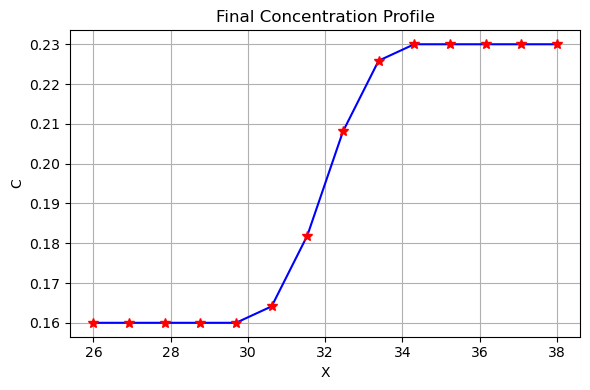

<br>

`F_bulk = 0.236697 J/m²

F_grad = 0.236826 J/m²

F_inte = 0.473523 J/m²`

<br>

A smooth diffuse interface between $c_{gamma}^e$ and $c_{gamma'}^e$ was obtained. The interfacial energy per unit area, $F_{int} = \int {(f_{bulk} + f_{grad}) dx}$ was evaluated numerically, yielding:

<br>

$$
F_{bulk} = 0.237 \frac {J}{m^2} \text{, } F_{grad} = 0.237 \frac {J}{m^2} \text{, } F_{int} = 0.474 \frac {J}{m^2} \text{, } 
$$

<br>

The near equality $ F_{bulk} \approx F_{grad} $ indicates a well-resolved equilibrium interface, consistent with the expected balance between bulk driving force and gradient penalty in a conserved Cahn–Hilliard system.

<br><br>


**Numerical setup (2-D, conserved concentration field)**

<br>

The Ni–Al binary system containing the two equilibrium phases γ and γ′ was extended to two spatial dimensions to study the temporal evolution of the conserved composition field $c(x,y,t)$. The system was initialized as a random mixture around the mean composition to mimic early-stage spinodal decomposition.

<br>

The computational domain was square, with $L_x = L_y = 100$ nm and spatial resolution $\delta x = \delta y = 1$ nm. No-flux boundary conditions were imposed on the chemical potential ($ \frac {\partial \mu} {\partial n} = 0$) to ensure global mass conservation. The simulation was performed for $10^3$ time steps with  $\delta t = 10^{-2}$.

<br>

![2D spinodal decomposition](2D%20spinodal%20decomposition.gif)

<br>

The evolution captures the early stages of spinodal decomposition, during which compositional fluctuations amplify and interconnected γ and γ′ domains begin to form. The morphology coarsens progressively as the simulation advances. Representative frames and an animation illustrate the spatial redistribution of solute and the conserved character of the phase separation process.